In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [167]:
Modelling_Data = pd.read_csv(r'C:\Users\user\Downloads\Fraudulent_Transaction_Detection_for_Finlora_Company\Finlora_dataset\artifacts\Engineered_Data.csv')

In [168]:
Modelling_Data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,day_of_week,is weekend,late_night_hour,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,False,US,...,18,0,0,0,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,True,CA,...,20,0,0,0,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,False,US,...,23,0,0,0,0,0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,False,US,...,1,1,0,0,0,0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,False,US,...,9,1,0,0,0,0,0,0,0,0


In [169]:
Modelling_Data['timestamp'] = pd.to_datetime(Modelling_Data['timestamp'])

In [170]:
categorical_features = Modelling_Data.select_dtypes(include=['object','bool']).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

In [171]:
numerical_features = Modelling_Data.select_dtypes(include=['int','float']).columns.drop('is_fraud')
numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is weekend', 'late_night_hour', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [172]:
all_features =list(categorical_features)+list(numerical_features)
print(all_features)

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is weekend', 'late_night_hour', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


Train_test Split

The data is split into:80% of data used to train the model and 20% is reserved to test the performance of the unseen data.

It is strongly recomended to sort the dataset chronologically before doing the trsin- test split. Since your dataset has a timestamp column, th order of evenrt matrers.this will prevent data leakage, help precdict the future transations since model will trained on the past transactions hence mimicing the real scenerio.

Features like:txn_velocity_1h,txn-velocity-24h.new_device,account_age_days.new_account depend on historical order.if data is not orderd by time,these features can become incorrect.

In [173]:
#sorting by timestamp
Modelling_Data = Modelling_Data.sort_values(by="timestamp")

#80/20 train_test split
split_index = int(len(Modelling_Data)*0.8)#This determins where the dataset should be split
train_Modelling_data = Modelling_Data.iloc[:split_index] #training on future transactions
test_Modelling_Data = Modelling_Data.iloc[split_index:] #testing on past transactions

#prepare x and y 
x_train = train_Modelling_data[all_features]
y_train = train_Modelling_data['is_fraud']
x_test = test_Modelling_Data[all_features]
y_test = test_Modelling_Data['is_fraud']

print(f"\nx_train:{x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


x_train:(8643, 28), y_train: (8643,)
x_test: (2161, 28), y_test: (2161,)


In [174]:
#Building preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers =[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop = 'first', sparse_output=False, handle_unknown='ignore'),categorical_features)
    ]
)


### Training Logistic regression with a balanced class weight

In [175]:
#Create logistic Regression model
lr_model = LogisticRegression(
    class_weight = 'balanced',
    random_state = 42,
    max_iter = 1000
)

#Build the complete pipeline
pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('classifer',lr_model)
    ]
)

#Train the pipeline 
pipeline.fit(x_train, y_train)

#Make predictions
y_pred_lr = pipeline.predict(x_test)
y_proba_lr = pipeline.predict_proba(x_test)[:,1]

#Evaluation
print("Logistic Regressionn Result:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names =['Genuine','Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")


Logistic Regressionn Result:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1853
       Fraud       0.80      0.95      0.87       308

    accuracy                           0.96      2161
   macro avg       0.90      0.95      0.92      2161
weighted avg       0.96      0.96      0.96      2161


Confusion Matrix:
[[1781   72]
 [  16  292]]

ROC_AUC Score: 0.9836


### Confusion Matrix for linear regression

<Figure size 800x600 with 0 Axes>

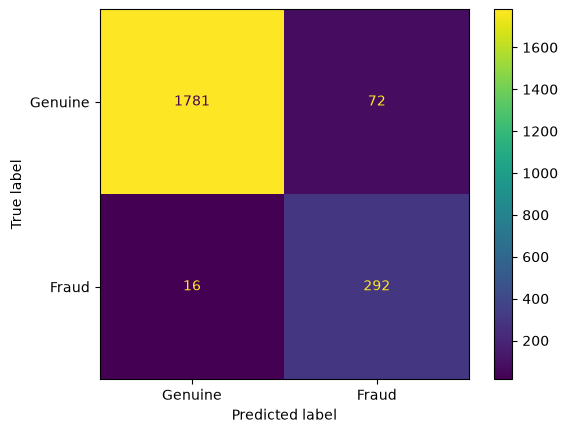

In [176]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_lr),display_labels=['Genuine','Fraud'])
plt.figure(figsize=(8,6))
cm.plot()

### Training Random forest with balanced class weight

In [177]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model= RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)

#Build the complete pipeline
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)

# Train the pipeline(using raw X_train, not processed)
pipeline_rf.fit(x_train, y_train)

# Make predictions
y_pred_rf = pipeline_rf.predict(x_test)
y_proba_rf =pipeline_rf.predict_proba(x_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matirix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")




Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1853
       Fraud       0.97      0.92      0.94       308

    accuracy                           0.98      2161
   macro avg       0.98      0.96      0.97      2161
weighted avg       0.98      0.98      0.98      2161


Confusion Matirix:
[[1843   10]
 [  25  283]]

ROC_AUC Score: 0.9777


### Confusion Matrix for Random Forest 

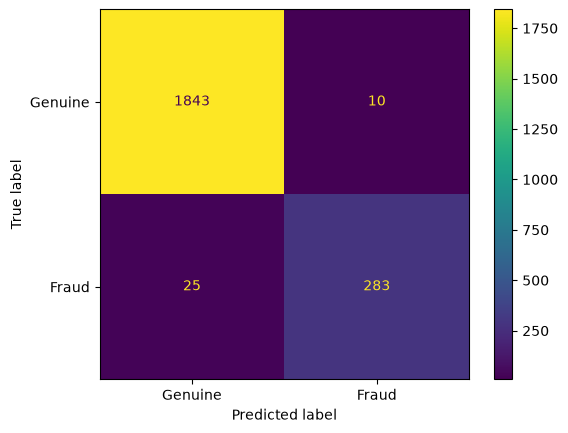

In [178]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine','Fraud'])
cm.plot()

In [179]:
from xgboost import XGBClassifier

# Calculate scale pos weight for imbalance in xgboost classifier 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

#Build the complete pipeline
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifer', xgb_model)
    ]
)

#Train the pipeline(using raw x_train, not processed)
pipeline_xgb.fit(x_train, y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(x_test)
y_proba_xgb = pipeline_xgb.predict_proba(x_test)[:, 1]

#Evaluation
print("XGBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuuie', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuuie       0.99      0.99      0.99      1853
       Fraud       0.95      0.92      0.94       308

    accuracy                           0.98      2161
   macro avg       0.97      0.96      0.96      2161
weighted avg       0.98      0.98      0.98      2161


Confusion Matrix:
[[1839   14]
 [  25  283]]

ROC_AUC Score: 0.9693


### Confusion martrix for xgboost 

<Figure size 800x600 with 0 Axes>

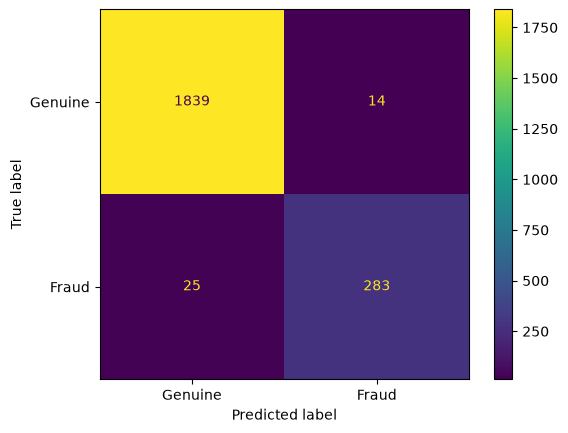

In [180]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine','Fraud'])
plt.figure(figsize=(8,6))
cm.plot()

### SHAP ANALYSIS

SHAP is a technique used to explain machine learning predictions- especially complex models like tree ensembles- in a way that shows how each feature contribuites to a decision,

SHAP answers this question:"Why did model say this transaction is fraud?"

it does this by assigning each feature a contribution value(positive or negative) to the prediction.SHAP is used to interpret model predictions by quantifying the contribution of each feature to fraud risk. This enables transparency in decision-making, helped identify key fraud drivers such as transaction velocity and ip risk score, and provided actionable insights for fraud analysts and business stakeholders.

SHAP is based on Game Theory, specifically shapley values. it fairly distributes the "credit" of a prediction across features.

In [181]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [182]:
import shap
import xgboost

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

SHAP version: 0.52.0
XGBoost version: 3.4.1


In [183]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

#Get the preprocessor from pipeline and transform raw x_test
x_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(x_test)

# Get the XGBoost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifer']

# Get booster and calculate SHAP values 
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(x_test_processed)

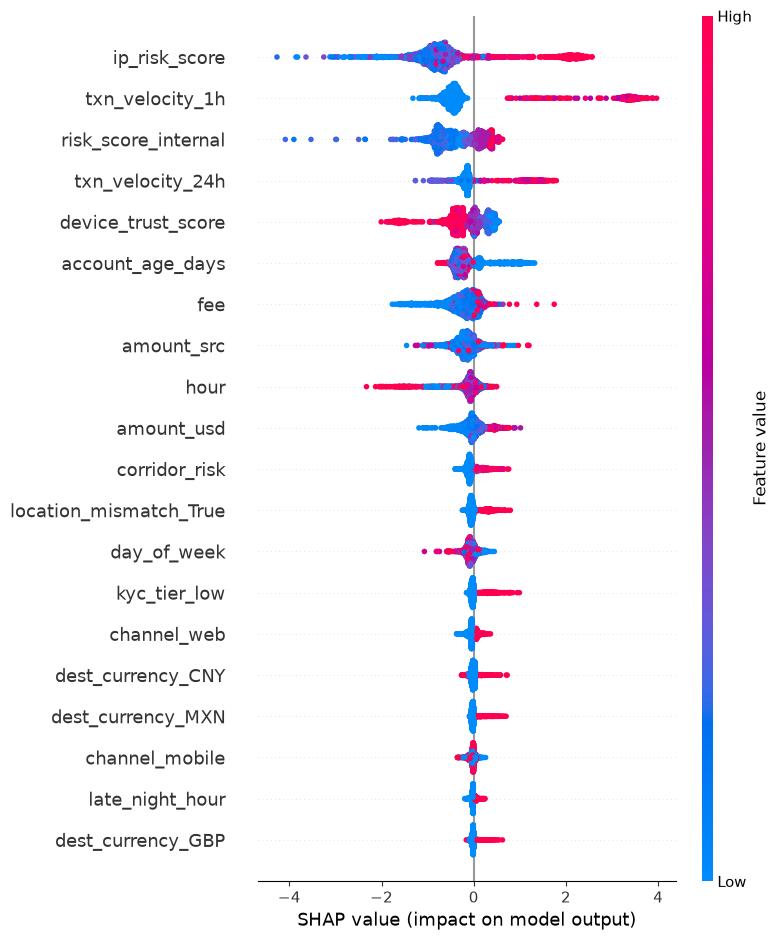

In [184]:
# Creating a clean feature name for the shap plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num__","").replace("cat__","")for name in feature_names]

x_test_processed_df = pd.DataFrame(
    x_test_processed,
    columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_gb, x_test_processed_df)
plt.show()

This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction). The Blue color represents Low feature value while the red color represents High feature value.

The Left part of the plot (negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.

The SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.

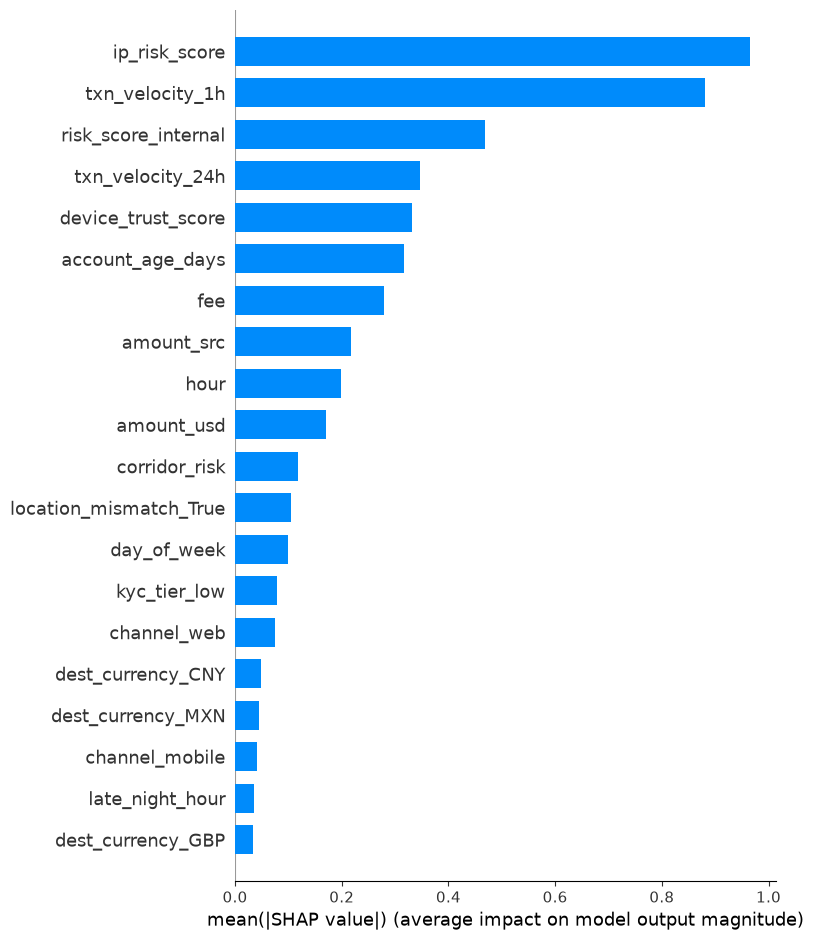

In [185]:
# Summary bar plot
shap.summary_plot(shap_values_gb, x_test_processed_df, plot_type="bar")
plt.show()

### Model registering

In [187]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DagsHub
import dagshub
dagshub.init(repo_owner='kemiopendoor247', 
             repo_name='Fraudulent_Transaction_Detection_for_Finlora_Company', 
             mlflow=True)



Initialized MLflow to track repo "kemiopendoor247/Fraudulent_Transaction_Detection_for_Finlora_Company"

Repository kemiopendoor247/Fraudulent_Transaction_Detection_for_Finlora_Company initialized!

In [195]:
# Set experiment
mlflow.set_experiment("Fraudulent_Transaction_Detection_for_Finlora_Company")

# start MLflow run and register model.
with mlflow.start_run() as run:
    # Log model parameters
    mlflow.log_params(xgb_model.get_params())

    # Make predicitons using the pipeline
    y_pred = pipeline_xgb.predict(x_test)
    y_pred_proba = pipeline_xgb.predict_proba(x_test)[:,1]

    # Log matrics
    mlflow.log_metrics({
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall' : recall_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba)
    })

    # Log the entire pipeline (prepreocessor + model) with cloudpickle serialzation
    mlflow.sklearn.log_model(
        pipeline_xgb,
        "xgboost_fraud_detection_pipeline",
        registered_model_name="Fraud_Detecion_XGBoost_pipeline",
        serialization_format= 'cloudpickle'

    )

    print(f"Model registered successfully!")
    print(f"Run ID: {run.info.run_id}")




2026/09/20 05:35:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/20 05:35:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Fraud_Detecion_XGBoost_pipeline'.
2026/09/20 05:35:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Fraud_Detecion_XGBoost_pipeline, version 1
Created version '1' of model 'Fraud_Detecion_XGBoost_pipeline'.


Model registered successfully!
Run ID: beb4bb98743a4b8c91f1ed30b7e09fda
🏃 View run nosy-croc-836 at: https://dagshub.com/kemiopendoor247/Fraudulent_Transaction_Detection_for_Finlora_Company.mlflow/#/experiments/0/runs/beb4bb98743a4b8c91f1ed30b7e09fda
🧪 View experiment at: https://dagshub.com/kemiopendoor247/Fraudulent_Transaction_Detection_for_Finlora_Company.mlflow/#/experiments/0
